# Simulation helps compare with your experimental observations.

### 1: Use [XQueryer](https://xqueryer.caobin.asia/query) to identify the phase.

### 2: Simulate in `PyXplore`

In [1]:
# import PyXplore package
from PyXplore import WPEM
import pandas as pd

Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead

██╗    ██╗██████╗ ███████╗███╗   ███╗
██║    ██║██╔══██╗██╔════╝████╗ ████║
██║ █╗ ██║██████╔╝█████╗  ██╔████╔██║
██║███╗██║██╔═══╝ ██╔══╝  ██║╚██╔╝██║
╚███╔███╔╝██║     ███████╗██║ ╚═╝ ██║
 ╚══╝╚══╝ ╚═╝     ╚══════╝╚═╝     ╚═╝                                                  

A Diffraction Refinement Software
Bin Cao, HKUST(Guangzhou), https://bin-cao.github.io
Paper : https://arxiv.org/abs/2602.16372
URL : https://github.com/Bin-Cao/PyWPEM
Executed on : 2026-05-24 14:41:38  | Have a great day.


the space group of input crystal is : P 1
cif file parse completed
atom locations claculated by parsed cif file
retrieval of all reciprocal vectors satisfying the diffraction geometry is done
extinction peaks are distinguished
There are 13 extinction peaks
Diffraction condition judgment end !
The input crystal system is: Orthorhombic  |  The initial lattice constants : 6.985205 8.534946 16.120259 90.0 90.0 90.0


WPEM simulates the peaks as the default Voigt functions
Initilized with default peak's shape
The nearest neighbor atoms are : ['S6+', 'O2-', 1.4729]


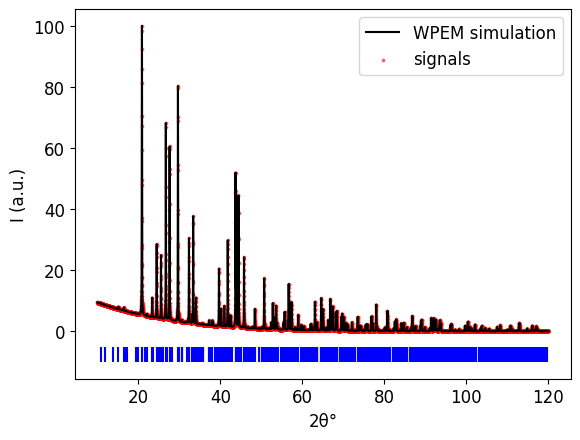

XRD simulation process of WPEM is completed !


<Figure size 640x480 with 0 Axes>

In [20]:
FHKL_square, two_theta_sim, intensity_sim = WPEM.XRDSimulation(
    filepath='PSO.cif',
    two_theta_range=(10, 120, 0.01),
    bacI=True,
    GrainSize=30,
    orientation=[-0.1, 0.1],
    thermo_vib=0.1,
    zero_shift=0.01
)

In [21]:
intensity_sim

[9.466817197412286,
 9.462073694524088,
 9.457332241546673,
 9.452592840369698,
 9.44785549301889,
 9.443120201664849,
 9.438386968632615,
 9.433655796411871,
 9.428926687668028,
 9.42419964525416,
 9.419474672223846,
 9.414751771845173,
 9.410030947615763,
 9.405312203279134,
 9.400595542842415,
 9.395880970595531,
 9.391168491132097,
 9.386458109372123,
 9.381749830586664,
 9.377043660424802,
 9.372339604942935,
 9.367637670636832,
 9.362937864476697,
 9.358240193945448,
 9.353544667080746,
 9.348851292521067,
 9.344160079556252,
 9.339471038183216,
 9.334784179167148,
 9.330099514109097,
 9.325417055520584,
 9.320736816906015,
 9.316058812854086,
 9.311383059139017,
 9.30670957283307,
 9.302038372431728,
 9.297369477993161,
 9.292702911293905,
 9.288038696003,
 9.28337685787699,
 9.278717424978861,
 9.274060427924198,
 9.269405900158548,
 9.264753878270648,
 9.260104402346803,
 9.255457516372841,
 9.250813268690969,
 9.246171712520315,
 9.241532906551605,
 9.236896915628087,
 9.2322

In [22]:
two_theta_sim

array([ 10.01,  10.02,  10.03, ..., 119.98, 119.99, 120.  ])

In [23]:
latt_dis

[9.467152364459857,
 9.462403411477426,
 9.45765651295247,
 9.452911670772442,
 9.448168886960863,
 9.443428163686143,
 9.43868950327113,
 9.433952908203327,
 9.429218381145967,
 9.424485924949956,
 9.419755542666715,
 9.415027237562185,
 9.41030101313183,
 9.40557687311705,
 9.40085482152285,
 9.39613486263703,
 9.391417001051117,
 9.386701241683024,
 9.381987589801744,
 9.37727605105428,
 9.372566631494992,
 9.367859337617626,
 9.363154176390365,
 9.358451155294134,
 9.353750282364626,
 9.349051566238366,
 9.34435501620327,
 9.339660642254344,
 9.334968455154907,
 9.330278466504172,
 9.325590688811841,
 9.320905135580553,
 9.316221821397264,
 9.31154076203451,
 9.306861974562901,
 9.302185477476327,
 9.29751129083142,
 9.29283943640324,
 9.288169937859417,
 9.283502820955166,
 9.27883811375222,
 9.274175846865,
 9.269516053737997,
 9.264858770958998,
 9.260204038613487,
 9.25555190068661,
 9.250902405520039,
 9.246255606332557,
 9.241611561814718,
 9.236970336809835,
 9.2323320030959

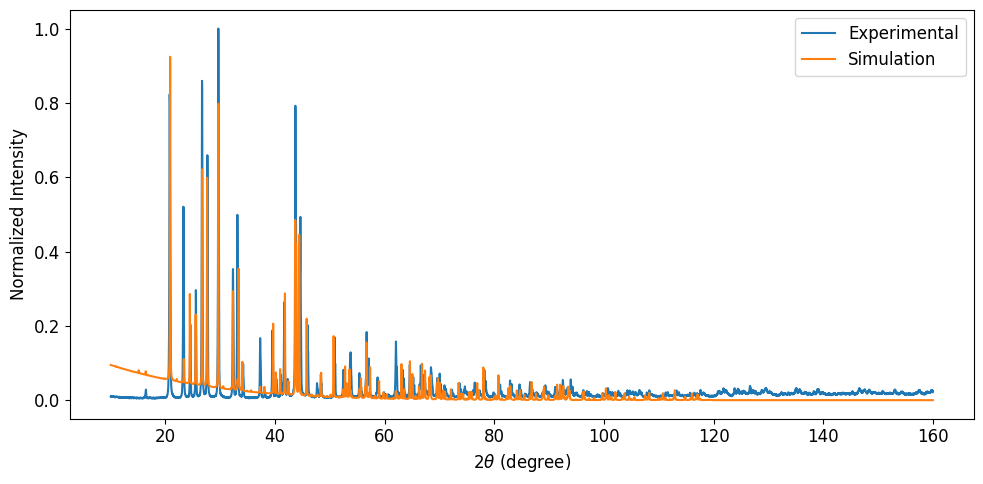

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error




# CSV format:
# 2theta,intensity

exp_df = pd.read_csv('PSO.csv')

two_theta_exp = exp_df.iloc[:, 0].values
intensity_exp = exp_df.iloc[:, 1].values

# =========================================================
intensity_sim = intensity_sim / np.max(intensity_sim)
intensity_exp = intensity_exp / np.max(intensity_exp)

# Interpolate Simulation onto Experimental Grid
# =========================================================
interp_func = interp1d(
    two_theta_sim,
    intensity_sim,
    bounds_error=False,
    fill_value=0
)

intensity_sim_interp = interp_func(two_theta_exp)

# Plot Comparison
# =========================================================
plt.figure(figsize=(10, 5))

plt.plot(
    two_theta_exp,
    intensity_exp,
    label='Experimental',
    linewidth=1.5
)

plt.plot(
    two_theta_exp,
    intensity_sim_interp,
    label='Simulation',
    linewidth=1.5
)

plt.xlabel(r'2$\theta$ (degree)', fontsize=12)
plt.ylabel('Normalized Intensity', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

### 3: Simulate in `SimXRD` | Paper : [ICLR 2025 ](https://openreview.net/forum?id=mkuB677eMM)

#### pip install Pysimxrd

In [31]:
from Pysimxrd import generator
from ase.db import connect

# choosing crystal (id=8) for an illustration
database = connect('demo.db')
entry_id = 8

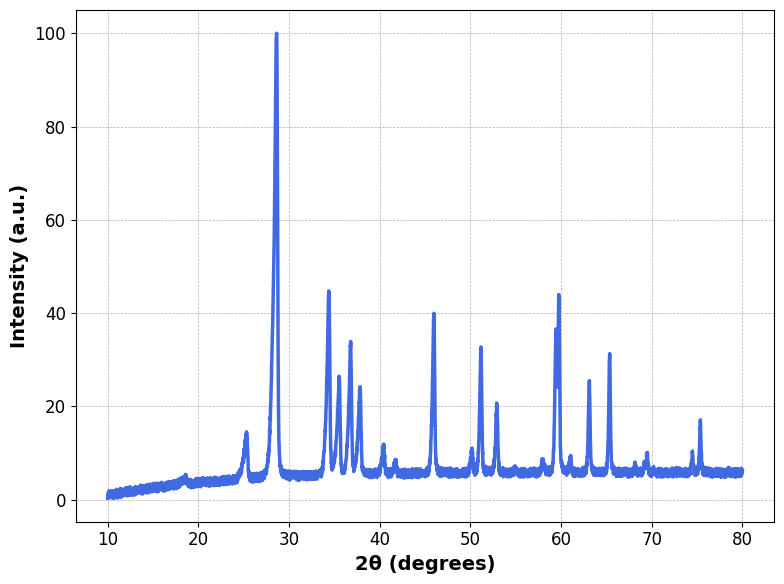

In [32]:
import matplotlib.pyplot as plt

x, y = generator.parser(database, entry_id)


plt.figure(figsize=(8, 6)) 
plt.plot(x, y, color='royalblue', linewidth=2.5) 


plt.xlabel('2θ (degrees)', fontsize=14, weight='bold')
plt.ylabel('Intensity (a.u.)', fontsize=14, weight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


plt.grid(True, which='both', linestyle='--', linewidth=0.5) 
plt.tight_layout()  #

plt.savefig('./xrd_pattern1.png', dpi=300) 
plt.show() 

### [more details ](https://github.com/Bin-Cao/SimXRD/tree/main/sim)